In [4]:
import numpy as np
import pandas as pd

In [5]:
FILES = [
"/Users/joeyli/skillvsluck/data/european_soccer/csv/original/Original_Matches.csv",
]
season_map = {
    f"I{i}": f"{2025 - i}/{2026 - i}" 
    for i in range(1, 25)
}
frames = []
for fp in FILES:
    df_i = pd.read_csv(fp, low_memory=False, on_bad_lines='skip')
    frames.append(df_i)

df_raw = pd.concat(frames, ignore_index=True)


columns =df_raw.columns

df_raw.sample(n=20)


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
74818,E2,2012-02-26,NaN,Sheffield Weds,Sheffield United,NaN,1395.39,0.0,4.0,9.0,...,1.97,0.0,1.95,1.86,0.6488,0.1296,0.0176,0.0765,0.0496,0.0779
142765,E1,2017-11-18,NaN,QPR,Aston Villa,1455.57,1526.54,6.0,8.0,4.0,...,1.87,0.0,1.90,1.95,0.1445,0.1735,0.0348,0.0870,0.5280,0.0322
110072,IRL,2015-03-13,19:45:00,Bohemians,Galway,NaN,NaN,4.0,7.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136910,MEX,2017-05-11,03:06:00,Guadalajara Chivas,Atlas,NaN,NaN,5.0,6.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146345,ARG,2018-02-24,20:00:00,Defensa y Justicia,Patronato,NaN,NaN,1.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109869,E3,2015-03-07,NaN,Carlisle,Exeter,NaN,NaN,3.0,3.0,1.0,...,1.88,-0.3,2.21,1.68,0.3670,0.4931,0.0373,0.0428,0.0291,0.0308
80506,E2,2012-09-29,NaN,Sheffield United,Notts County,NaN,NaN,5.0,9.0,5.0,...,2.05,-0.5,2.07,1.79,0.2567,0.2690,0.0219,0.3676,0.0675,0.0173
40367,G1,2007-04-15,NaN,PAOK,Xanthi,1443.18,1410.55,7.0,10.0,5.0,...,1.55,0.0,1.19,3.63,NaN,NaN,NaN,NaN,NaN,NaN
171203,ROM,2020-06-03,18:30:00,Astra,FC Botosani,1426.10,NaN,2.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72443,E1,2011-11-26,NaN,Cardiff,Nottm Forest,1565.82,1492.92,7.0,11.0,6.0,...,2.00,-0.5,2.01,1.84,0.1029,0.5995,0.0534,0.0233,0.1041,0.1167


In [6]:
columns

Index(['Division', 'MatchDate', 'MatchTime', 'HomeTeam', 'AwayTeam', 'HomeElo',
       'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTHome',
       'FTAway', 'FTResult', 'HTHome', 'HTAway', 'HTResult', 'HomeShots',
       'AwayShots', 'HomeTarget', 'AwayTarget', 'HomeFouls', 'AwayFouls',
       'HomeCorners', 'AwayCorners', 'HomeYellow', 'AwayYellow', 'HomeRed',
       'AwayRed', 'OddHome', 'OddDraw', 'OddAway', 'MaxHome', 'MaxDraw',
       'MaxAway', 'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 'HandiSize',
       'HandiHome', 'HandiAway', 'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB',
       'C_PHB'],
      dtype='object')

In [7]:
need = ["Division","MatchDate", "HomeTeam", "AwayTeam", "FTHome", "FTAway", "FTResult", "OddHome","OddDraw","OddAway"]
have = [c for c in need if c in df_raw.columns]
df = df_raw[have].copy()


score_map_home = {"H": 3, "D": 1, "A": 0}
score_map_away = {"H": 0, "D": 1, "A": 3}

df.insert(loc=need.index("FTResult")+1, column="ScoreHome", value=df["FTResult"].map(score_map_home))
df.insert(loc=need.index("FTResult")+2, column="ScoreAway", value=df["FTResult"].map(score_map_away))


df.sample(n=10)


df_Bundesliga = df[df["Division"] == "D1"].copy()
df_La_Liga = df[df["Division"] == "SP1"].copy()
df_premier_league = df[df["Division"] == "E0"].copy()
df_serie_a = df[df["Division"] == "I1"].copy()

In [8]:
df_Bundesliga=df_Bundesliga.drop(columns = "Division")
df_La_Liga=df_La_Liga.drop(columns = "Division")
df_premier_league = df_premier_league.drop(columns = "Division")
df_serie_a = df_serie_a.drop(columns = "Division")

In [9]:
df_Bundesliga

,MatchDate,HomeTeam,AwayTeam,FTHome,FTAway,FTResult,ScoreHome,ScoreAway,OddHome,OddDraw,OddAway
39,2000-08-11,Dortmund,Hansa Rostock,1.0,0.0,H,3.0,0.0,1.50,3.40,5.00
42,2000-08-12,Bayern Munich,Hertha,4.0,1.0,H,3.0,0.0,1.30,4.50,6.00
43,2000-08-12,Freiburg,Stuttgart,4.0,0.0,H,3.0,0.0,2.40,3.10,2.50
44,2000-08-12,Hamburg,Munich 1860,2.0,2.0,D,1.0,1.0,1.80,3.30,3.80
45,2000-08-12,Kaiserslautern,Bochum,0.0,1.0,A,0.0,3.0,1.50,3.40,4.60
...,...,...,...,...,...,...,...,...,...,...,...
230384,2025-05-17,Hoffenheim,Bayern Munich,0.0,4.0,A,0.0,3.0,5.11,5.23,1.50
230385,2025-05-17,Mainz,Leverkusen,2.0,2.0,D,1.0,1.0,2.18,3.94,2.94
230386,2025-05-17,M'gladbach,Wolfsburg,0.0,1.0,A,0.0,3.0,2.19,4.23,2.79
230387,2025-05-17,RB Leipzig,Stuttgart,2.0,3.0,A,0.0,3.0,1.99,4.24,3.19


In [10]:
df_Bundesliga["MatchDate"] = pd.to_datetime(df_Bundesliga["MatchDate"], errors="coerce", dayfirst=False)
df_La_Liga["MatchDate"] = pd.to_datetime(df_La_Liga["MatchDate"], errors="coerce", dayfirst=False)
df_serie_a["MatchDate"] = pd.to_datetime(df_serie_a["MatchDate"], errors="coerce", dayfirst=False)
df_premier_league["MatchDate"] = pd.to_datetime(df_premier_league["MatchDate"], errors="coerce", dayfirst=False)


def get_season(date):
    if pd.isna(date):
        return None
    year = date.year
    if date.month >= 8:  # August → season starts this year
        return f"{year}" #/{year+1}
    else:  # Jan–July → season is last year
        return f"{year-1}" #/{year}


df_Bundesliga["season"] = df_Bundesliga["MatchDate"].apply(get_season)
df_La_Liga["season"] = df_La_Liga["MatchDate"].apply(get_season)
df_serie_a["season"] = df_serie_a["MatchDate"].apply(get_season)
df_premier_league["season"] = df_premier_league["MatchDate"].apply(get_season)


# Move season to the front of the df
col = "season"

# Get all columns, remove the one you want to move
cols = [col] + [c for c in df_Bundesliga.columns if c != col]

# Reorder the DataFrame
df_Bundesliga = df_Bundesliga[cols]
df_serie_a = df_serie_a[cols]
df_La_Liga = df_La_Liga[cols]
df_premier_league = df_premier_league[cols]



In [11]:
final_Bundesliga_df = df_Bundesliga.sort_values(
    ["season", "MatchDate"], 
    ascending=[False, False],   # season desc, date desc
    ignore_index=True
)
final_serie_a_df = df_serie_a.sort_values(
    ["season", "MatchDate"], 
    ascending=[False, False],   # season desc, date desc
    ignore_index=True
)
final_premier_league_df = df_premier_league.sort_values(
    ["season", "MatchDate"], 
    ascending=[False, False],   # season desc, date desc
    ignore_index=True
)
final_La_Liga_df = df_La_Liga.sort_values(
    ["season", "MatchDate"], 
    ascending=[False, False],   # season desc, date desc
    ignore_index=True
)


# Normalizing all of the data to fit the format of premier league and serie a
final_Bundesliga_df = final_Bundesliga_df.rename(columns={
    "MatchDate": "date",
    "HomeTeam": "home_team",
    "AwayTeam": "away_team",
    "FTHome": "hometeamgoals",
    "FTAway": "awayteamgoals",
    "FTResult": "hometeamresult",
    "ScoreHome": "home_team_points",
    "ScoreAway": "away_team_points"
    # OddHome, OddDraw, OddAway stay the same
})

final_La_Liga_df = final_La_Liga_df.rename(columns={
    "MatchDate": "date",
    "HomeTeam": "home_team",
    "AwayTeam": "away_team",
    "FTHome": "hometeamgoals",
    "FTAway": "awayteamgoals",
    "FTResult": "hometeamresult",
    "ScoreHome": "home_team_points",
    "ScoreAway": "away_team_points"
    # OddHome, OddDraw, OddAway stay the same
})
final_serie_a_df = final_serie_a_df.rename(columns={
    "MatchDate": "date",
    "HomeTeam": "home_team",
    "AwayTeam": "away_team",
    "FTHome": "hometeamgoals",
    "FTAway": "awayteamgoals",
    "FTResult": "hometeamresult",
    "ScoreHome": "home_team_points",
    "ScoreAway": "away_team_points"
    # OddHome, OddDraw, OddAway stay the same
})

final_premier_league_df = final_premier_league_df.rename(columns={
    "MatchDate": "date",
    "HomeTeam": "home_team",
    "AwayTeam": "away_team",
    "FTHome": "hometeamgoals",
    "FTAway": "awayteamgoals",
    "FTResult": "hometeamresult",
    "ScoreHome": "home_team_points",
    "ScoreAway": "away_team_points"
    # OddHome, OddDraw, OddAway stay the same
})

def get_result(result):
    if pd.isna(result):
        return None
    if result == "H":  # when home wins we replace with 1
        return 1 #
    if result == "D":  # when draw we replace with 0
        return 0 
    else:  # 
        return -1 # when loss we replace with -1
    
final_La_Liga_df["hometeamresult"] = final_La_Liga_df["hometeamresult"].apply(get_result)
final_Bundesliga_df["hometeamresult"] = final_Bundesliga_df["hometeamresult"].apply(get_result)
final_serie_a_df["hometeamresult"] = final_serie_a_df["hometeamresult"].apply(get_result)
final_premier_league_df["hometeamresult"] = final_premier_league_df["hometeamresult"].apply(get_result)



In [ ]:
final_Bundesliga_df.to_csv("bundesliga.csv", index=False)
final_La_Liga_df.to_csv("la_liga.csv", index=False)
final_premier_league_df.to_csv("premier_league.csv", index=False)


In [ ]:


df2 = pd.DataFrame({'season': "2019"}, index = [1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909]) # Update rows 0 and 2 of 'A'
final_serie_a_df.update(df2)
final_serie_a_df.to_csv("serie_a.csv", index=False)



,season,date,home_team,away_team,hometeamgoals,awayteamgoals,hometeamresult,home_team_points,away_team_points,OddHome,OddDraw,OddAway
1890,2020,2020-09-26,Cagliari,Lazio,0.0,2.0,-1,0.0,3.0,4.87,4.01,1.68
1891,2020,2020-09-26,Sampdoria,Benevento,2.0,3.0,-1,0.0,3.0,2.02,3.52,3.69
1892,2020,2020-09-26,Inter,Fiorentina,4.0,3.0,1,3.0,0.0,1.55,4.27,5.92
1893,2020,2020-09-21,Milan,Bologna,2.0,0.0,1,3.0,0.0,1.58,4.31,5.48
1894,2020,2020-09-20,Parma,Napoli,0.0,2.0,-1,0.0,3.0,5.13,4.16,1.63
1895,2020,2020-09-20,Genoa,Crotone,4.0,1.0,1,3.0,0.0,1.91,3.59,4.03
1896,2020,2020-09-20,Sassuolo,Cagliari,1.0,1.0,0,1.0,1.0,1.95,3.80,3.67
1897,2020,2020-09-20,Juventus,Sampdoria,3.0,0.0,1,3.0,0.0,1.28,5.86,10.22
1898,2020,2020-09-19,Fiorentina,Torino,1.0,0.0,1,3.0,0.0,1.87,3.69,4.13
1899,2020,2020-09-19,Verona,Roma,0.0,0.0,0,1.0,1.0,3.82,3.65,1.96


In [15]:
final_Bundesliga_df.mean(numeric_only=True)



hometeamgoals       1.667509
awayteamgoals       1.280909
hometeamresult      0.159931
home_team_points    1.616458
away_team_points    1.136666
OddHome             2.541850
OddDraw             3.917847
OddAway             4.311903
dtype: float64

In [16]:
final_La_Liga_df.mean(numeric_only=True)


hometeamgoals       1.545515
awayteamgoals       1.127109
hometeamresult      0.193939
home_team_points    1.664853
away_team_points    1.083037
OddHome             2.568322
OddDraw             3.873251
OddAway             4.714402
dtype: float64

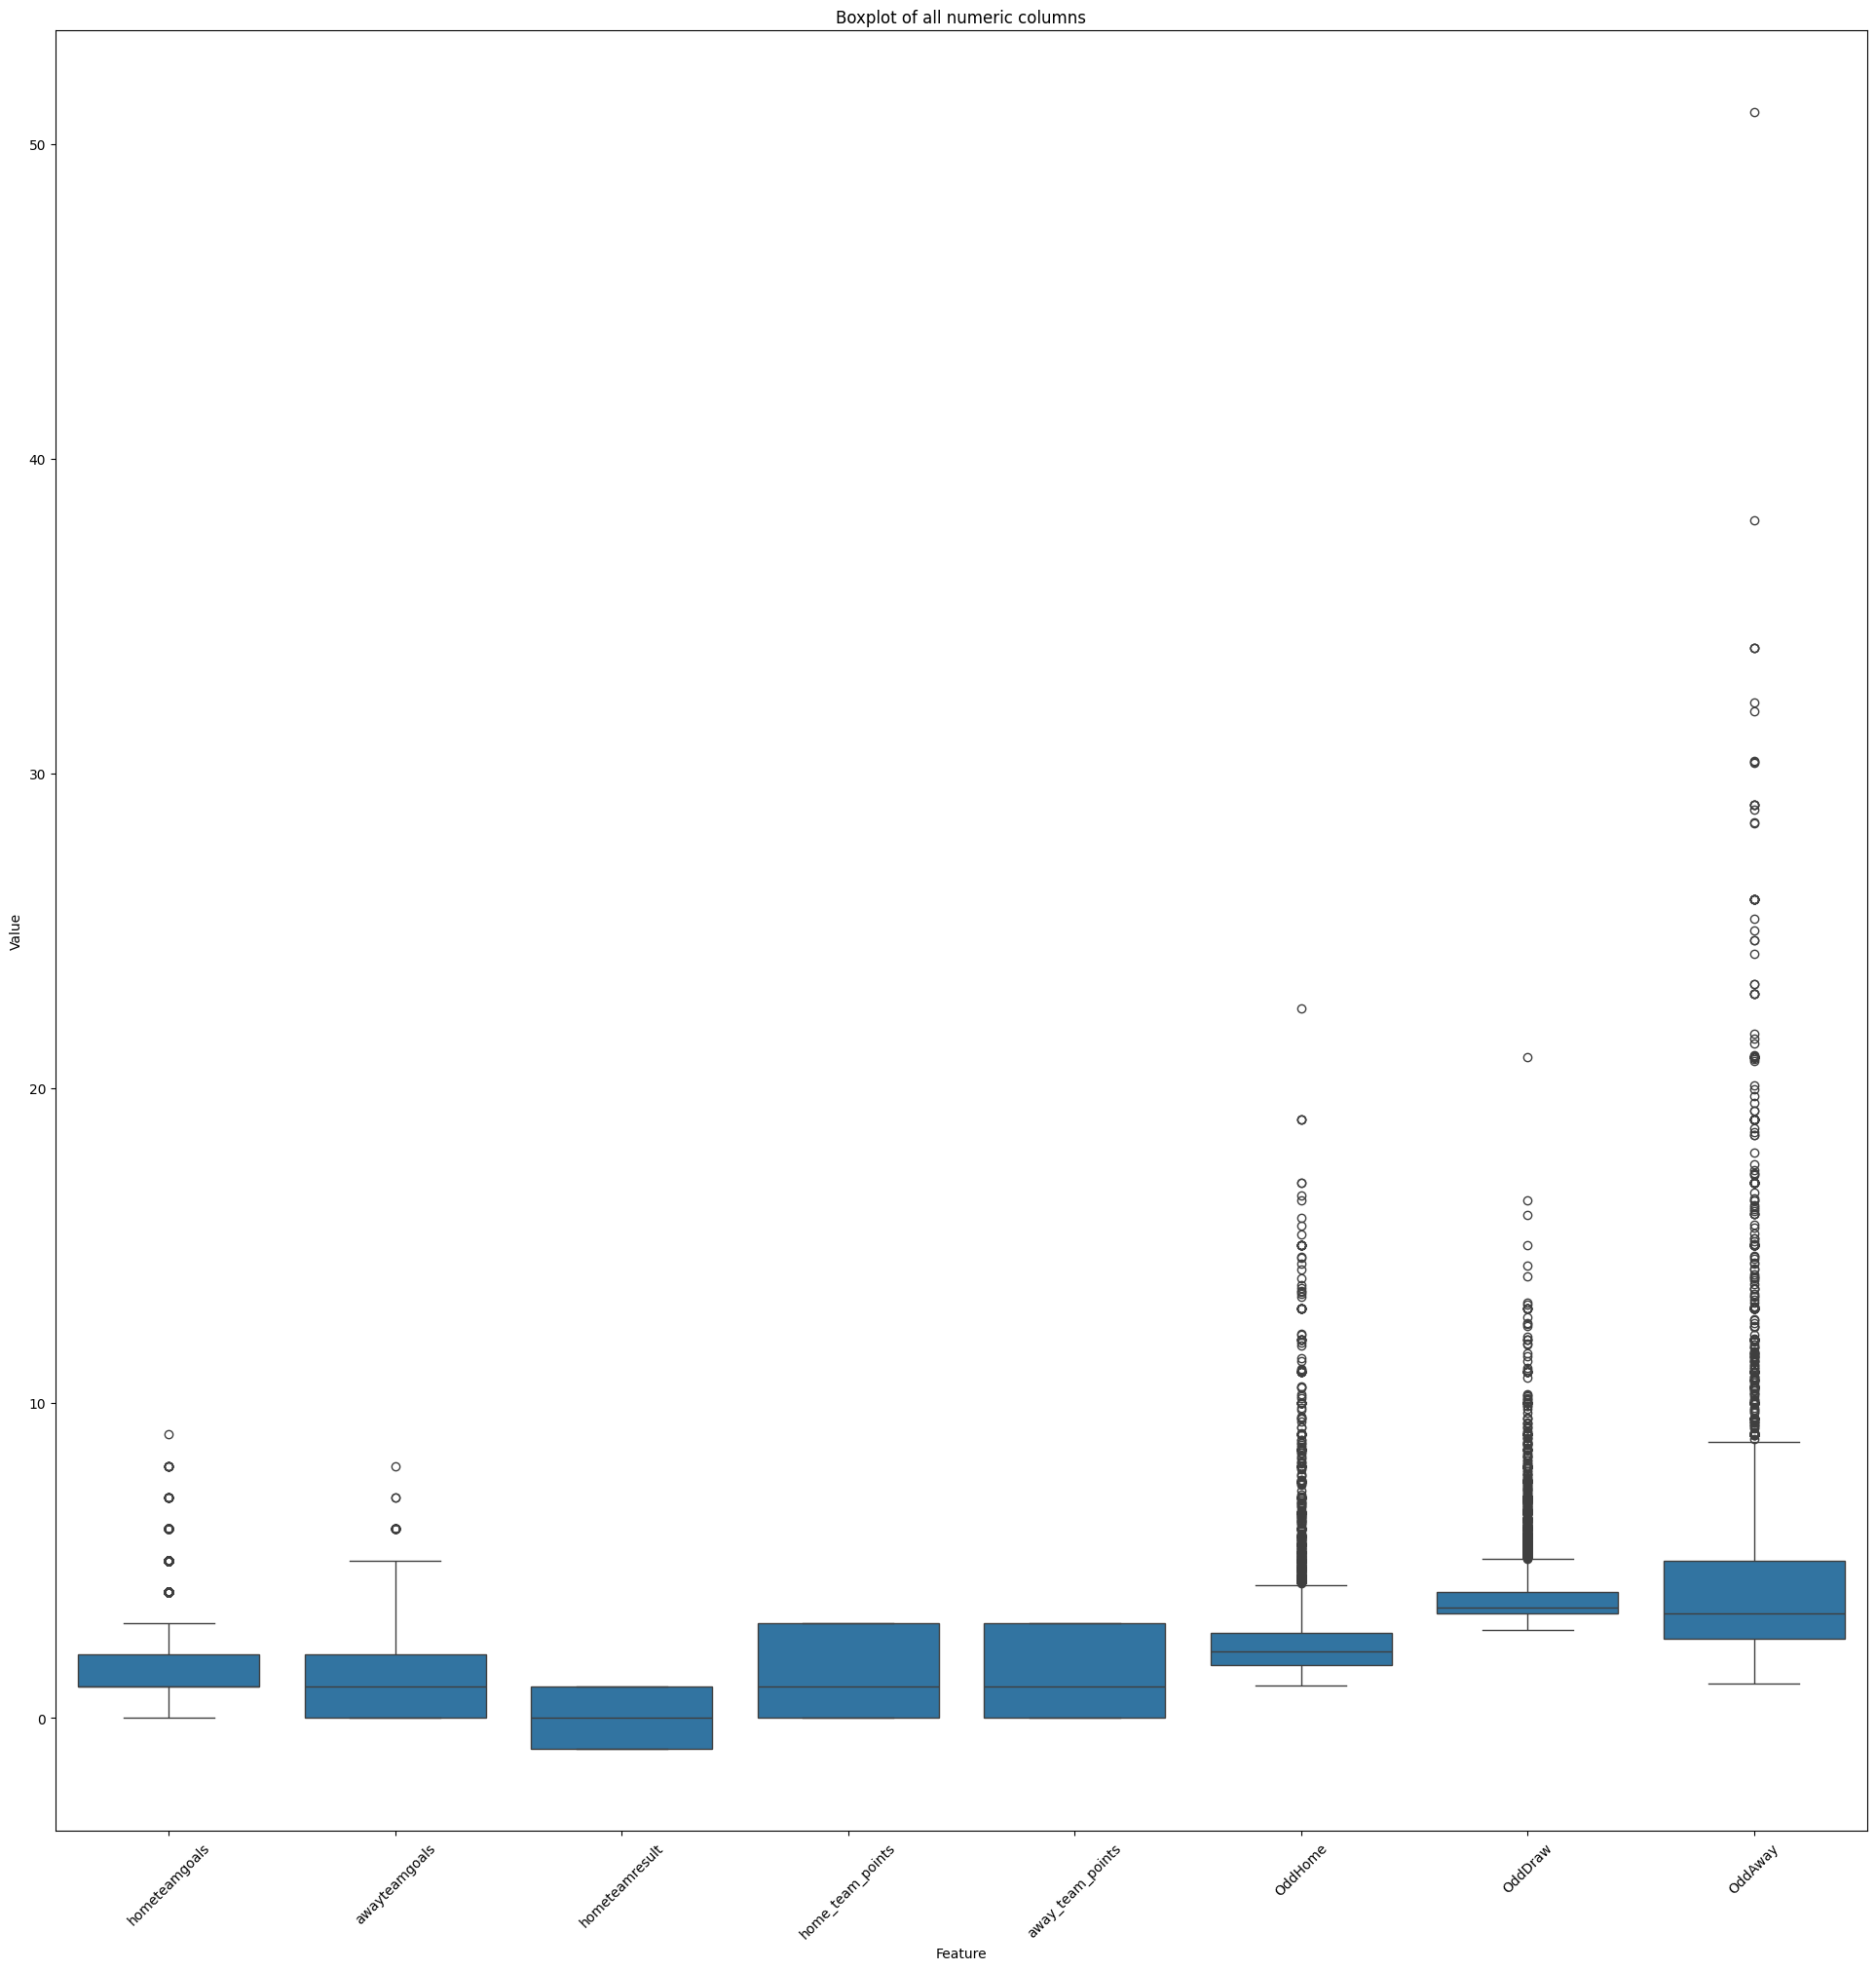

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


# Melt the DataFrame to long format
num_df = final_Bundesliga_df.select_dtypes(include=['int64', 'float64'])
melted_df = num_df.melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(24,24))
sns.boxplot(x='Feature', y='Value', data=melted_df)
plt.xticks(rotation=45)
plt.title("Boxplot of all numeric columns")
plt.show()


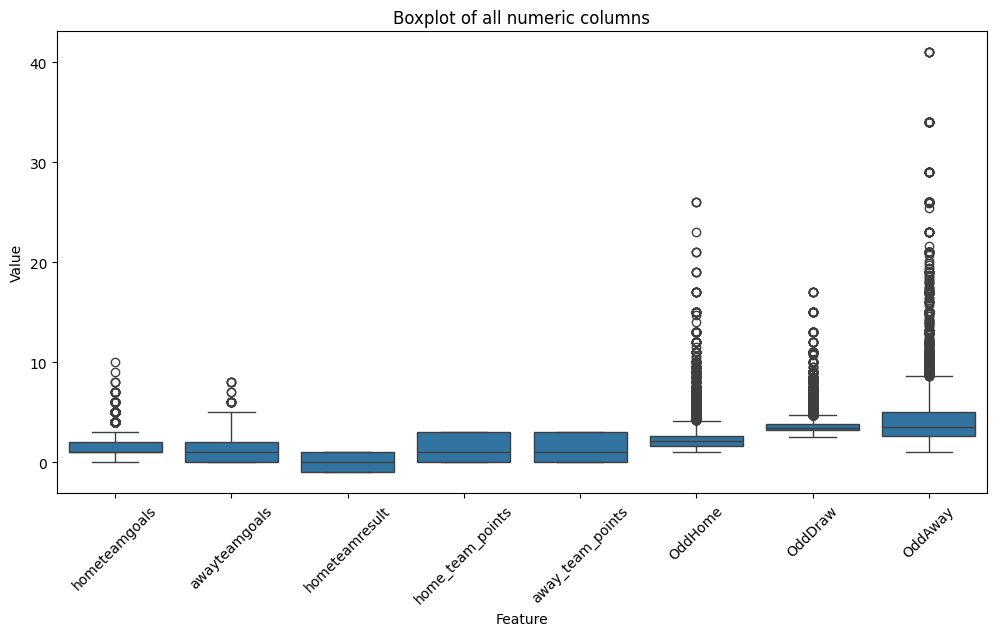

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


# Melt the DataFrame to long format
num_df = final_La_Liga_df.select_dtypes(include=['int64', 'float64'])
melted_df = num_df.melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(12,6))
sns.boxplot(x='Feature', y='Value', data=melted_df)
plt.xticks(rotation=45)
plt.title("Boxplot of all numeric columns")
plt.show()

In [19]:
final_Bundesliga_df.groupby("season").agg("count").reset_index()

,season,date,home_team,away_team,hometeamgoals,awayteamgoals,hometeamresult,home_team_points,away_team_points,OddHome,OddDraw,OddAway
0,2000,314,314,314,314,314,314,314,314,314,314,314
1,2001,298,298,298,298,298,298,298,298,225,225,225
2,2002,290,290,290,290,290,290,290,290,288,288,288
3,2003,194,194,194,194,194,194,194,194,194,194,194
4,2004,306,306,306,306,306,306,306,306,306,306,306
5,2005,306,306,306,306,306,306,306,306,306,306,306
6,2006,306,306,306,306,306,306,306,306,306,306,306
7,2007,306,306,306,306,306,306,306,306,306,306,306
8,2008,306,306,306,306,306,306,306,306,306,306,306
9,2009,306,306,306,306,306,306,306,306,306,306,306


In [28]:
final_serie_a_df.groupby("season").agg("count").reset_index()


,season,date,home_team,away_team,hometeamgoals,awayteamgoals,hometeamresult,home_team_points,away_team_points,OddHome,OddDraw,OddAway
0,2000,306,306,306,306,306,306,306,306,299,299,299
1,2001,306,306,306,306,306,306,306,306,237,237,237
2,2002,306,306,306,306,306,306,306,306,302,302,302
3,2003,194,194,194,194,194,194,194,194,170,170,170
4,2004,300,300,300,300,300,300,300,300,291,291,291
5,2005,380,380,380,380,380,380,380,380,378,378,378
6,2006,380,380,380,380,380,380,380,380,380,380,380
7,2007,380,380,380,380,380,380,380,380,380,380,380
8,2008,380,380,380,380,380,380,380,380,380,380,380
9,2009,380,380,380,380,380,380,380,380,379,379,379


In [21]:
final_premier_league_df.groupby("season").agg("count").reset_index()


,season,date,home_team,away_team,hometeamgoals,awayteamgoals,hometeamresult,home_team_points,away_team_points,OddHome,OddDraw,OddAway
0,2000,380,380,380,380,380,380,380,380,380,380,380
1,2001,380,380,380,380,380,380,380,380,297,297,297
2,2002,380,380,380,380,380,380,380,380,380,380,380
3,2003,335,335,335,335,335,335,335,335,335,335,335
4,2004,335,335,335,335,335,335,335,335,335,335,335
5,2005,380,380,380,380,380,380,380,380,380,380,380
6,2006,380,380,380,380,380,380,380,380,380,380,380
7,2007,380,380,380,380,380,380,380,380,380,380,380
8,2008,380,380,380,380,380,380,380,380,380,380,380
9,2009,380,380,380,380,380,380,380,380,380,380,380


In [22]:
final_La_Liga_df.groupby("season").agg("count").reset_index()


,season,date,home_team,away_team,hometeamgoals,awayteamgoals,hometeamresult,home_team_points,away_team_points,OddHome,OddDraw,OddAway
0,2000,380,380,380,380,380,380,380,380,376,376,376
1,2001,380,380,380,380,380,380,380,380,300,300,300
2,2002,380,380,380,380,380,380,380,380,379,379,379
3,2003,380,380,380,380,380,380,380,380,375,375,375
4,2004,268,268,268,268,268,268,268,268,268,268,268
5,2005,380,380,380,380,380,380,380,380,380,380,380
6,2007,380,380,380,380,380,380,380,380,380,380,380
7,2008,380,380,380,380,380,380,380,380,380,380,380
8,2009,380,380,380,380,380,380,380,380,380,380,380
9,2010,380,380,380,380,380,380,380,380,380,380,380
